
### Langkah 1: Memuat Dataset
Pada langkah pertama, kita akan memuat dataset dummy yang berisi informasi tren pasar yang diambil dari berbagai sumber seperti media sosial, e-commerce, dan laporan industri. Dataset ini akan membantu kita menganalisis dan mendeteksi tren pasar yang relevan untuk UMKM.


In [ ]:

import pandas as pd
import numpy as np

# Load the dataset
dummy_df = pd.read_excel('13_deteksi_tren_pasar.xlsx')
dummy_df


,Trend ID,Trend Name,Platform,Mentions,Growth Rate (%),Sentiment,Date Detected
0,1,Trend D,Social Media,5683,36.809733,Positive,2023-01-01
1,2,Trend E,E-commerce,9594,32.195564,Positive,2023-01-02
2,3,Trend B,Social Media,7712,34.284683,Neutral,2023-01-03
3,4,Trend D,Industry Report,6393,30.153518,Neutral,2023-01-04
4,5,Trend C,Social Media,3328,20.474951,Positive,2023-01-05
...,...,...,...,...,...,...,...
95,96,Trend A,Social Media,1335,42.705599,Negative,2023-04-06
96,97,Trend B,Industry Report,8296,49.052460,Positive,2023-04-07
97,98,Trend B,Social Media,3964,32.870843,Positive,2023-04-08
98,99,Trend C,Industry Report,3800,41.509998,Neutral,2023-04-09



### Langkah 2: Visualisasi Data
Pada langkah kedua, kita akan memvisualisasikan beberapa data terkait tren pasar. Kita akan melihat distribusi jumlah sebutan tren dan membandingkan pertumbuhan tren pasar berdasarkan platform (media sosial, e-commerce, dan laporan industri). Visualisasi ini membantu kita memahami pola pertumbuhan tren pasar yang ada.


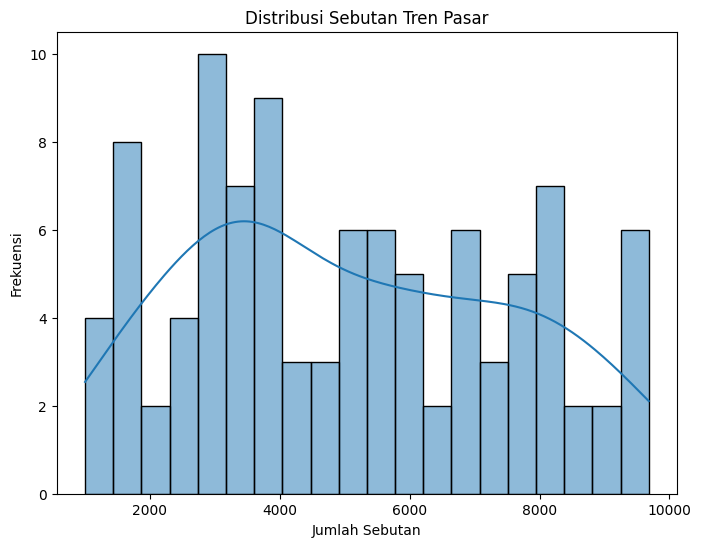

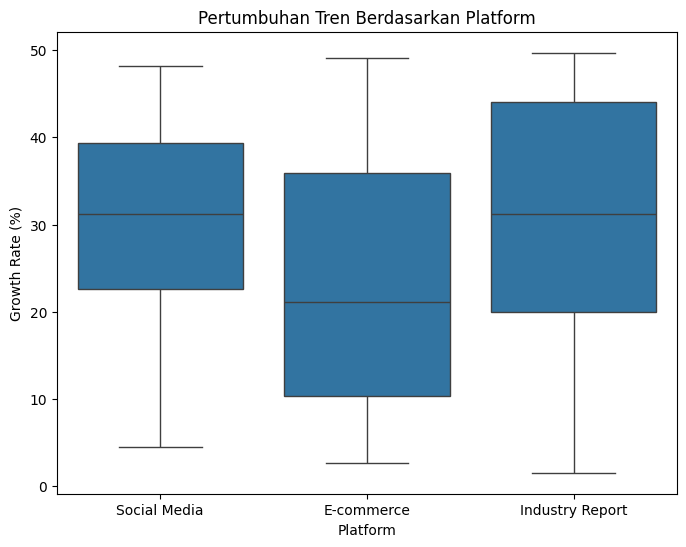

In [ ]:

# Langkah 2: Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi distribusi jumlah sebutan tren
plt.figure(figsize=(8, 6))
sns.histplot(dummy_df['Mentions'], bins=20, kde=True)
plt.title('Distribusi Sebutan Tren Pasar')
plt.xlabel('Jumlah Sebutan')
plt.ylabel('Frekuensi')
plt.show()

# Visualisasi pertumbuhan tren berdasarkan kategori platform
plt.figure(figsize=(8, 6))
sns.boxplot(x='Platform', y='Growth Rate (%)', data=dummy_df)
plt.title('Pertumbuhan Tren Berdasarkan Platform')
plt.xlabel('Platform')
plt.ylabel('Growth Rate (%)')
plt.show()



### Langkah 3: Preprocessing Data
Pada langkah ini, kita akan melakukan enkoding pada variabel sentimen dan platform menggunakan LabelEncoder dari scikit-learn. Hal ini diperlukan untuk memproses data dalam bentuk numerik, yang diperlukan oleh model pembelajaran mesin.


In [ ]:

# Langkah 3: Preprocessing Data
from sklearn.preprocessing import LabelEncoder

# Mengencode sentimen dan platform
label_encoder = LabelEncoder()
dummy_df['Sentiment'] = label_encoder.fit_transform(dummy_df['Sentiment'])
dummy_df['Platform'] = label_encoder.fit_transform(dummy_df['Platform'])

# Memeriksa data setelah preprocessing
dummy_df.head()


,Trend ID,Trend Name,Platform,Mentions,Growth Rate (%),Sentiment,Date Detected
0,1,Trend D,2,5683,36.809733,2,2023-01-01
1,2,Trend E,0,9594,32.195564,2,2023-01-02
2,3,Trend B,2,7712,34.284683,1,2023-01-03
3,4,Trend D,1,6393,30.153518,1,2023-01-04
4,5,Trend C,2,3328,20.474951,2,2023-01-05



### Langkah 4: Normalisasi Data
Pada langkah ini, kita akan melakukan normalisasi pada data numerik seperti jumlah sebutan dan laju pertumbuhan tren agar berada pada skala yang sama. Normalisasi ini meningkatkan performa model yang akan digunakan pada langkah-langkah selanjutnya.


In [ ]:

# Langkah 4: Normalisasi Data
from sklearn.preprocessing import StandardScaler

# Melakukan normalisasi pada kolom mentions dan growth rate
scaler = StandardScaler()
dummy_df[['Mentions', 'Growth Rate (%)']] = scaler.fit_transform(dummy_df[['Mentions', 'Growth Rate (%)']])

# Memeriksa data setelah normalisasi
dummy_df.head()


,Trend ID,Trend Name,Platform,Mentions,Growth Rate (%),Sentiment,Date Detected
0,1,Trend D,2,0.250224,0.597368,2,2023-01-01
1,2,Trend E,0,1.842181,0.264890,2,2023-01-02
2,3,Trend B,2,1.076120,0.415423,1,2023-01-03
3,4,Trend D,1,0.539226,0.117749,1,2023-01-04
4,5,Trend C,2,-0.708370,-0.579649,2,2023-01-05



### Langkah 5: Membagi Data Train dan Test
Pada langkah ini, kita akan membagi dataset menjadi data latih (train) dan data uji (test) dengan proporsi 80% untuk latih dan 20% untuk uji. Pembagian ini memungkinkan kita untuk melatih model pada data latih dan mengujinya dengan data uji yang belum pernah dilihat sebelumnya.


In [ ]:

# Langkah 5: Membagi Data Train dan Test
from sklearn.model_selection import train_test_split

# Memisahkan data menjadi fitur (X) dan target (y)
X = dummy_df[['Platform', 'Mentions', 'Growth Rate (%)', 'Sentiment']]
y = dummy_df['Trend Name']

# Membagi data menjadi data latih (train) dan data uji (test) dengan proporsi 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menampilkan ukuran data train dan test
(X_train.shape, X_test.shape)


((80, 4), (20, 4))


### Langkah 6: Melatih Model
Pada langkah ini, kita akan menggunakan algoritma Random Forest untuk melatih model klasifikasi tren pasar. Model ini akan membantu kita mengidentifikasi pola dalam data yang mengarah pada deteksi tren pasar yang relevan. Kita juga akan melihat pentingnya fitur berdasarkan model yang telah dilatih.


In [ ]:

# Langkah 6: Melatih Model
from sklearn.ensemble import RandomForestClassifier

# Membuat dan melatih model RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Melihat fitur penting dari model
model.feature_importances_


array([0.12986138, 0.34698873, 0.40574412, 0.11740576])


### Langkah 7: Evaluasi Model
Pada langkah ini, kita akan mengevaluasi kinerja model dengan menggunakan data uji. Kita akan menghitung akurasi dan menampilkan laporan klasifikasi untuk menilai performa model dalam mendeteksi tren pasar yang relevan.


In [ ]:

# Langkah 7: Evaluasi Model
from sklearn.metrics import accuracy_score, classification_report

# Memprediksi hasil pada data uji
y_pred = model.predict(X_test)

# Menghitung akurasi dan menampilkan laporan klasifikasi
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

accuracy, report


(0.3,
 '              precision    recall  f1-score   support\n\n     Trend A       0.25      0.20      0.22         5\n     Trend B       0.20      0.20      0.20         5\n     Trend C       0.00      0.00      0.00         4\n     Trend D       0.50      0.60      0.55         5\n     Trend E       0.50      1.00      0.67         1\n\n    accuracy                           0.30        20\n   macro avg       0.29      0.40      0.33        20\nweighted avg       0.26      0.30      0.28        20\n')


### Langkah 8: Prediksi
Pada langkah terakhir, kita akan menggunakan model yang telah dilatih untuk memprediksi tren pasar berdasarkan data baru. Ini memungkinkan kita untuk mendeteksi tren pasar yang akan datang dan membuat keputusan yang lebih responsif berdasarkan tren tersebut.


In [ ]:
# Langkah 8: Prediksi
# Melakukan prediksi pada data baru (dummy)
new_data = pd.DataFrame({
    'Platform': [label_encoder.transform(['E-commerce'])[0]],
    'Mentions': [1500], # Remove scaler.transform here
    'Growth Rate (%)': [25], # Remove scaler.transform here
    'Sentiment': ['Positive']  # Keep as string for now
})
# Apply scaler.transform to 'Mentions' and 'Growth Rate (%)' columns together
new_data[['Mentions', 'Growth Rate (%)']] = scaler.transform(new_data[['Mentions', 'Growth Rate (%)']])

# Instead of replacing with 'Neutral', handle unseen labels during prediction
try:
    new_data['Sentiment'] = label_encoder.transform(new_data['Sentiment'])
except ValueError as e:
    # Handle the unseen label, for example, by assigning a default value or raising an exception
    unseen_label = str(e).split(": ")[1].strip("'")
    print(f"Warning: Sentiment '{unseen_label}' is unseen. Assigning a default value (e.g., -1).")
    # Replace -1 with your desired default value
    new_data['Sentiment'] = -1

# Now predict the trend name
prediction = model.predict(new_data)
prediction

array(['Trend B'], dtype=object)


## Keterangan Penting

Notebook ini menggunakan data dummy. Agar model ini dapat menghasilkan prediksi yang lebih akurat dan relevan, **kustomisasi lebih lanjut diperlukan**. Beberapa hal yang perlu dipertimbangkan antara lain:

1. **Penyempurnaan Dataset**: Data yang digunakan adalah data dummy yang bersifat acak. Untuk hasil yang lebih baik, dataset harus diisi dengan data kemacetan lalu lintas yang lebih realistis dan sesuai dengan kondisi lokal yang relevan.
   
2. **Penyesuaian Fitur**: Beberapa fitur, seperti jumlah kendaraan, kecepatan rata-rata, atau status sinyal lalu lintas, perlu penyesuaian atau penambahan fitur lain yang lebih berdampak pada prediksi kemacetan.

3. **Parameter Model**: Untuk hasil prediksi yang lebih optimal, Anda dapat menyesuaikan parameter model SVM atau mencoba model lain yang lebih sesuai dengan karakteristik data.

4. **Validasi Model**: Melakukan validasi dengan data nyata dan cross-validation untuk mengevaluasi kinerja model.

Dengan penyesuaian yang tepat, model ini dapat memberikan prediksi kemacetan yang lebih akurat dan bermanfaat untuk mengatur lalu lintas di kota dan meningkatkan mobilitas perkotaan.
